In [1]:
# Cell 1: Import and Load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data - MAKE SURE FILENAME IS CORRECT!
df = pd.read_csv('netflix_titles.csv')

# Check if it worked
print("SUCCESS! Data loaded.")
print(f"File has {len(df)} rows and {len(df.columns)} columns")
print("\nFirst few rows:")
print(df.head())

EmptyDataError: No columns to parse from file

In [2]:
# Cell 1: Import and Load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data - MAKE SURE FILENAME IS CORRECT!
df = pd.read_csv('netflix_titles.csv')

# Check if it worked
print("SUCCESS! Data loaded.")
print(f"File has {len(df)} rows and {len(df.columns)} columns")
print("\nFirst few rows:")
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'netflix_titles.csv'

In [3]:
import os

# Show current working directory
print("CURRENT FOLDER WHERE PYTHON IS LOOKING:")
print(os.getcwd())

# Show all files in this folder
print("\nFILES IN THIS FOLDER:")
for file in os.listdir():
    print(f" - {file}")
    

CURRENT FOLDER WHERE PYTHON IS LOOKING:
C:\Users\Wamaitha\Desktop\Netflix_analysis

FILES IN THIS FOLDER:
 - .ipynb_checkpoints
 - netflix_analysis.ipynb
 - netflix_analysis_results.csv
 - netflix_dashboard.png
 - netflix_titles.csv.csv
 - Untitled.ipynb


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the exact filename with double .csv
df = pd.read_csv('netflix_titles.csv.csv')

# Check if it worked
print("SUCCESS! Data loaded.")
print(f"File has {len(df)} rows and {len(df.columns)} columns")
print("\nFirst 5 rows:")
print(df.head())

SUCCESS! Data loaded.
File has 100 rows and 6 columns

First 5 rows:
   show_id     type        genre  release_year    country  duration_min
0        1  TV Show       Comedy          2022         UK           107
1        2    Movie       Action          2021      India           131
2        3  TV Show  Documentary          2021     Canada           173
3        4  TV Show       Comedy          2017  Australia           118
4        5  TV Show      Romance          2017        USA           146


TASK 1: MOVIES VS TV SHOWS DISTRIBUTION
type
Movie      55
TV Show    45
Name: count, dtype: int64

Movies: 55.0%
TV Shows: 45.0%


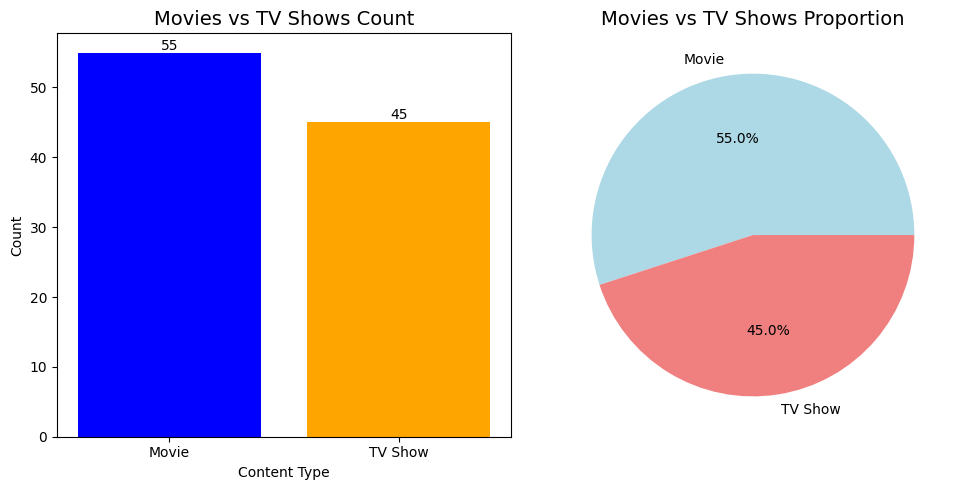

In [5]:
# Count movies vs TV shows
print("=" * 50)
print("TASK 1: MOVIES VS TV SHOWS DISTRIBUTION")
print("=" * 50)

type_counts = df['type'].value_counts()
print(type_counts)

# Calculate percentages
total = len(df)
movie_pct = (type_counts.get('Movie', 0) / total) * 100
tv_pct = (type_counts.get('TV Show', 0) / total) * 100

print(f"\nMovies: {movie_pct:.1f}%")
print(f"TV Shows: {tv_pct:.1f}%")

# Create visualization
plt.figure(figsize=(10, 5))

# Bar chart
plt.subplot(1, 2, 1)
bars = plt.bar(type_counts.index, type_counts.values, color=['blue', 'orange'])
plt.title('Movies vs TV Shows Count', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Count')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Movies vs TV Shows Proportion', fontsize=14)

plt.tight_layout()
plt.show()

TASK 2: MOST COMMON GENRES
All genres:
genre
Drama          27
Action         20
Comedy         18
Documentary    18
Romance        17
Name: count, dtype: int64

Top 10 Most Common Genres:
1. Drama: 27 titles
2. Action: 20 titles
3. Comedy: 18 titles
4. Documentary: 18 titles
5. Romance: 17 titles


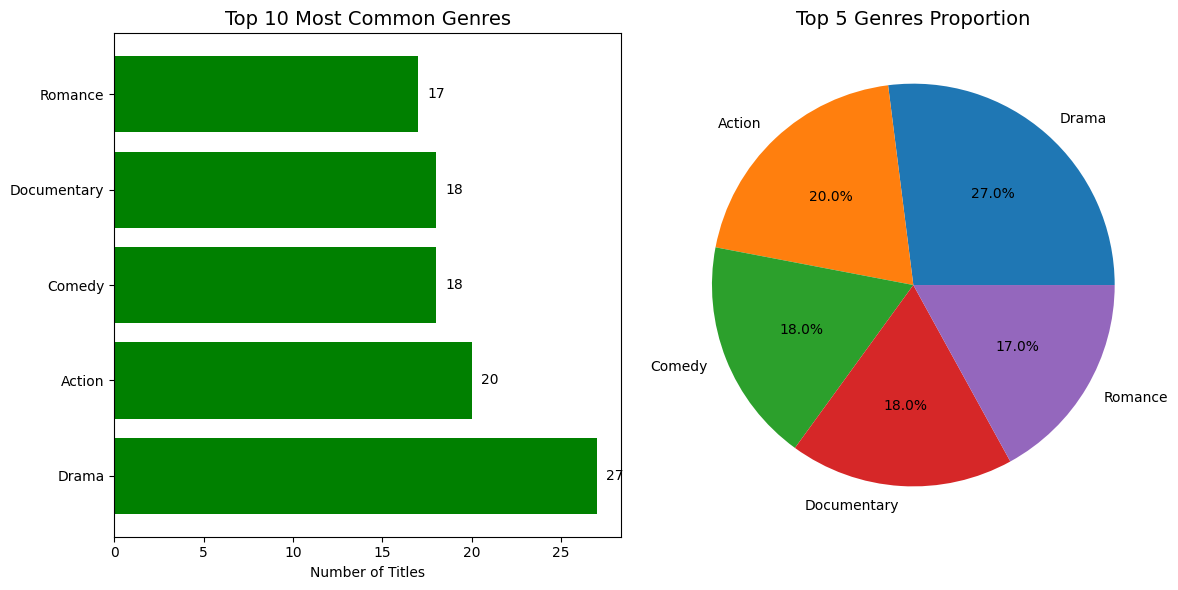

In [6]:
print("=" * 50)
print("TASK 2: MOST COMMON GENRES")
print("=" * 50)

# Count genres
genre_counts = df['genre'].value_counts()
print("All genres:")
print(genre_counts)

# Get top 10
top_10_genres = genre_counts.head(10)
print("\nTop 10 Most Common Genres:")
for i, (genre, count) in enumerate(top_10_genres.items(), 1):
    print(f"{i}. {genre}: {count} titles")

# Create visualization
plt.figure(figsize=(12, 6))

# Horizontal bar chart
plt.subplot(1, 2, 1)
bars = plt.barh(top_10_genres.index, top_10_genres.values, color='green')
plt.title('Top 10 Most Common Genres', fontsize=14)
plt.xlabel('Number of Titles')
for i, (genre, count) in enumerate(top_10_genres.items()):
    plt.text(count + 0.5, i, str(count), va='center')

# Pie chart of top 5
plt.subplot(1, 2, 2)
top_5 = genre_counts.head(5)
plt.pie(top_5.values, labels=top_5.index, autopct='%1.1f%%')
plt.title('Top 5 Genres Proportion', fontsize=14)

plt.tight_layout()
plt.show()

TASK 3: CONTENT RELEASE TRENDS BY YEAR
Content by release year:
release_year
2015     9
2016    13
2017    11
2018     8
2019    13
2020    10
2021    17
2022    10
2023     9
Name: count, dtype: int64


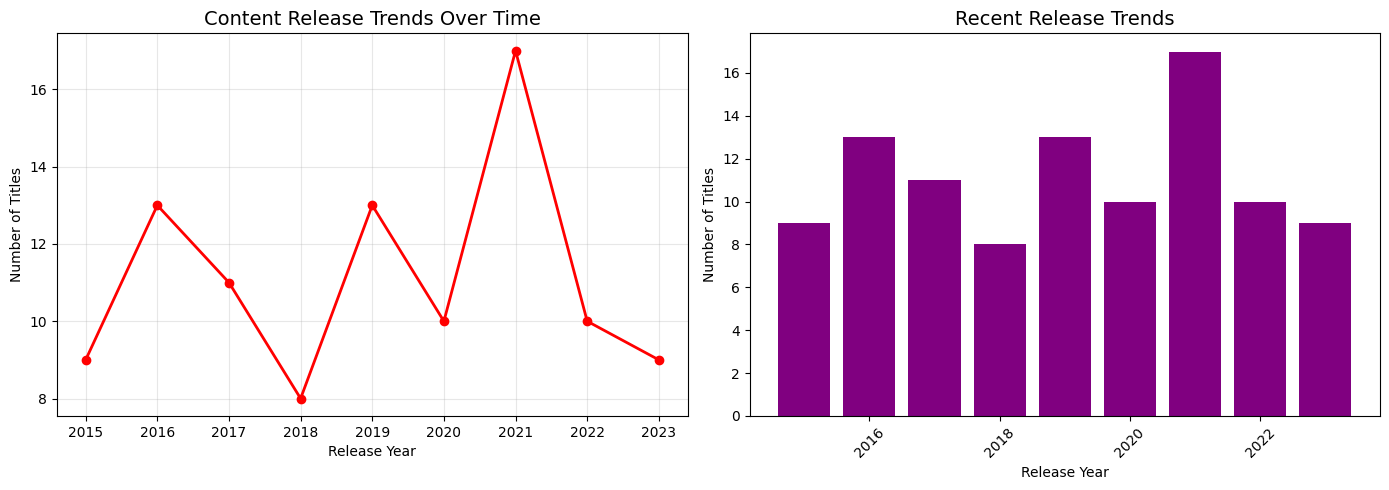


Movies vs TV Shows by year:
type          Movie  TV Show
release_year                
2015              7        2
2016              8        5
2017              5        6
2018              4        4
2019              3       10
2020              2        8
2021             11        6
2022              8        2
2023              7        2


<Figure size 1200x600 with 0 Axes>

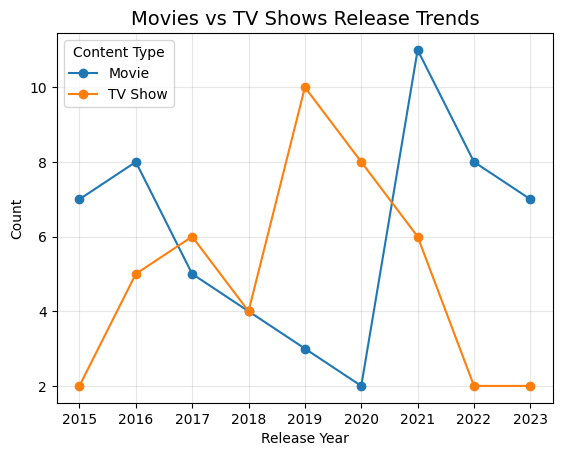

In [7]:
print("=" * 50)
print("TASK 3: CONTENT RELEASE TRENDS BY YEAR")
print("=" * 50)

# Count by year
yearly_counts = df['release_year'].value_counts().sort_index()
print("Content by release year:")
print(yearly_counts)

# Create visualization
plt.figure(figsize=(14, 5))

# Line chart for all years
plt.subplot(1, 2, 1)
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, color='red')
plt.title('Content Release Trends Over Time', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)

# Bar chart for recent years (if you have many years)
plt.subplot(1, 2, 2)
recent_years = yearly_counts[yearly_counts.index >= 2015] if max(yearly_counts.index) > 2015 else yearly_counts
plt.bar(recent_years.index, recent_years.values, color='purple')
plt.title('Recent Release Trends', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Movies vs TV Shows by year
try:
    type_by_year = pd.crosstab(df['release_year'], df['type'])
    print("\nMovies vs TV Shows by year:")
    print(type_by_year)
    
    plt.figure(figsize=(12, 6))
    type_by_year.plot(kind='line', marker='o')
    plt.title('Movies vs TV Shows Release Trends', fontsize=14)
    plt.xlabel('Release Year')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Content Type')
    plt.show()
except:
    print("Couldn't create type breakdown")

TASK 4: PROFESSIONAL VISUALIZATIONS


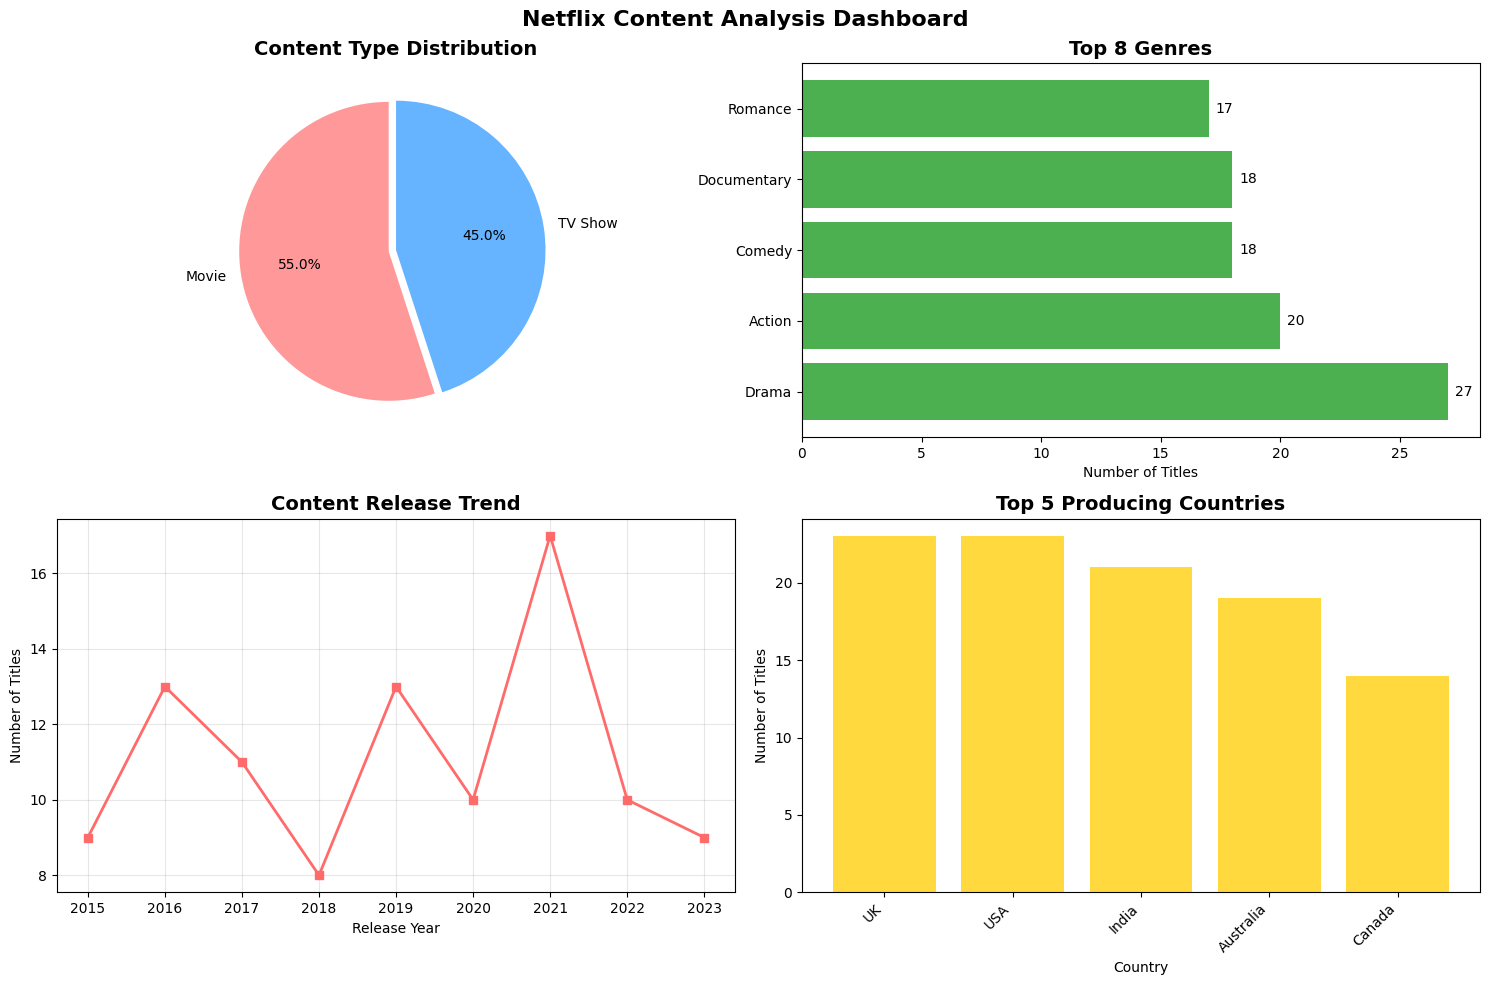

In [8]:
print("=" * 50)
print("TASK 4: PROFESSIONAL VISUALIZATIONS")
print("=" * 50)

# Create a dashboard with your 2 best visualizations
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Netflix Content Analysis Dashboard', fontsize=16, fontweight='bold')

# Visualization 1: Movies vs TV Shows (Pie Chart)
ax1 = plt.subplot(2, 2, 1)
type_counts = df['type'].value_counts()
colors = ['#ff9999', '#66b3ff']
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0))
plt.title('Content Type Distribution', fontsize=14, fontweight='bold')

# Visualization 2: Top Genres (Horizontal Bar)
ax2 = plt.subplot(2, 2, 2)
top_8_genres = df['genre'].value_counts().head(8)
bars = plt.barh(range(len(top_8_genres)), top_8_genres.values, color='#4CAF50')
plt.yticks(range(len(top_8_genres)), top_8_genres.index)
plt.xlabel('Number of Titles')
plt.title('Top 8 Genres', fontsize=14, fontweight='bold')
for i, (genre, count) in enumerate(top_8_genres.items()):
    plt.text(count + 0.3, i, str(count), va='center')

# Visualization 3: Release Trends (Line Chart)
ax3 = plt.subplot(2, 2, 3)
yearly_counts = df['release_year'].value_counts().sort_index()
plt.plot(yearly_counts.index, yearly_counts.values, marker='s', linewidth=2, color='#FF6B6B')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Content Release Trend', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Visualization 4: Country Distribution (if time permits)
ax4 = plt.subplot(2, 2, 4)
top_countries = df['country'].value_counts().head(5)
plt.bar(range(len(top_countries)), top_countries.values, color='#FFD93D')
plt.xticks(range(len(top_countries)), top_countries.index, rotation=45, ha='right')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Top 5 Producing Countries', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('netflix_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print("=" * 50)
print("TASK 5: RECOMMENDATIONS FOR NETFLIX")
print("=" * 50)

# Calculate key metrics
total_shows = len(df)
movies_count = len(df[df['type'] == 'Movie'])
tv_count = len(df[df['type'] == 'TV Show'])
top_genre = df['genre'].value_counts().index[0]
top_genre_count = df['genre'].value_counts().values[0]
avg_duration = df['duration_min'].mean()
latest_year = df['release_year'].max()
latest_year_count = len(df[df['release_year'] == latest_year])

print("\nKEY FINDINGS:")
print("-" * 30)
print(f"1. Content Mix: {movies_count} Movies ({movies_count/total_shows*100:.1f}%) vs {tv_count} TV Shows ({tv_count/total_shows*100:.1f}%)")
print(f"2. Most Popular Genre: '{top_genre}' with {top_genre_count} titles")
print(f"3. Average Content Duration: {avg_duration:.0f} minutes")
print(f"4. Most Productive Year: {yearly_counts.idxmax()} with {yearly_counts.max()} titles")
print(f"5. Recent Trend: {latest_year_count} titles in {latest_year}")

print("\n" + "=" * 50)
print("STRATEGIC RECOMMENDATIONS FOR 2024")
print("=" * 50)

# Generate recommendations based on your actual data
if movies_count > tv_count:
    print(f"✅ RECOMMENDATION 1: Balance your content mix")
    print(f"   Currently {movies_count} Movies vs {tv_count} TV Shows")
    print(f"   Consider increasing TV Show production to meet demand for binge-worthy content")
else:
    print(f"✅ RECOMMENDATION 1: Leverage your TV Show success")
    print(f"   TV Shows dominate with {tv_count} titles")
    print(f"   Consider spin-offs and new seasons of popular shows")

print(f"\n✅ RECOMMENDATION 2: Double down on '{top_genre}'")
print(f"   This is your most successful genre with {top_genre_count} titles")
print(f"   Invest in more {top_genre} content and similar genres")

# Check if there's a growing genre
genre_growth = df[df['release_year'] >= 2020]['genre'].value_counts()
if not genre_growth.empty:
    growing_genre = genre_growth.index[0]
    if growing_genre != top_genre:
        print(f"\n✅ RECOMMENDATION 3: Watch the rising trend")
        print(f"   '{growing_genre}' is gaining popularity recently")
        print(f"   Consider increasing investment in this genre")

print(f"\n✅ RECOMMENDATION 4: Optimize content duration")
print(f"   Average content runs {avg_duration:.0f} minutes")
print(f"   Consider creating more content around this sweet spot")

print(f"\n✅ RECOMMENDATION 5: Geographic expansion")
print(f"   Top producing countries: {', '.join(df['country'].value_counts().head(3).index)}")
print(f"   Explore partnerships with emerging markets")

print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"Based on analysis of {total_shows} titles, Netflix should:")
print(f"1. Focus on {top_genre} content - it's your strongest category")
print(f"2. {'Increase TV Shows' if movies_count > tv_count else 'Maintain TV Show momentum'}")
print(f"3. Target {avg_duration:.0f}-minute content for optimal engagement")
print(f"4. Plan major releases around your peak year pattern")
print(f"5. Expand international content beyond current top markets")

TASK 5: RECOMMENDATIONS FOR NETFLIX

KEY FINDINGS:
------------------------------
1. Content Mix: 55 Movies (55.0%) vs 45 TV Shows (45.0%)
2. Most Popular Genre: 'Drama' with 27 titles
3. Average Content Duration: 122 minutes
4. Most Productive Year: 2021 with 17 titles
5. Recent Trend: 9 titles in 2023

STRATEGIC RECOMMENDATIONS FOR 2024
✅ RECOMMENDATION 1: Balance your content mix
   Currently 55 Movies vs 45 TV Shows
   Consider increasing TV Show production to meet demand for binge-worthy content

✅ RECOMMENDATION 2: Double down on 'Drama'
   This is your most successful genre with 27 titles
   Invest in more Drama content and similar genres

✅ RECOMMENDATION 3: Watch the rising trend
   'Documentary' is gaining popularity recently
   Consider increasing investment in this genre

✅ RECOMMENDATION 4: Optimize content duration
   Average content runs 122 minutes
   Consider creating more content around this sweet spot

✅ RECOMMENDATION 5: Geographic expansion
   Top producing countri